## Setting Up

In [ ]:
home_dir = normalizePath("~")
relative_path = file.path("R programs")
full_path = file.path(home_dir, relative_path)
setwd(full_path)
getwd()

In [2]:
library(zoo)
library(TTR)
library(xts)
library(quantmod)
library(PerformanceAnalytics)
library(car)
library(tidyverse)
library(tidyquant)
library(FinancialInstrument)


── Conflicts ────────────────────────────────────────── tidyquant_conflicts() ──
✖ zoo::as.Date()                 masks base::as.Date()
✖ zoo::as.Date.numeric()         masks base::as.Date.numeric()
✖ dplyr::filter()                masks stats::filter()
✖ dplyr::first()                 masks xts::first()
✖ dplyr::lag()                   masks stats::lag()
✖ dplyr::last()                  masks xts::last()
✖ PerformanceAnalytics::legend() masks graphics::legend()
✖ dplyr::recode()                masks car::recode()
✖ purrr::some()                  masks car::some()
✖ quantmod::summary()            masks base::summary()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'FinancialInstrument'


The following object is masked from 'package:tidyr':

    spread




## Download the data and visualize the data

In [5]:
AMZN = getSymbols("AMZN", from = "2010-12-31",to = "2020-12-31", auto.assign = F)
head(AMZN)
AMZN = na.omit(AMZN)
dim(AMZN)

           AMZN.Open AMZN.High AMZN.Low AMZN.Close AMZN.Volume AMZN.Adjusted
2010-12-31    9.0980    9.1150   8.9755     9.0000    69038000        9.0000
2011-01-03    9.0685    9.3000   9.0605     9.2110   106628000        9.2110
2011-01-04    9.3075    9.3850   9.1890     9.2505   100636000        9.2505
2011-01-05    9.2050    9.3725   9.2035     9.3710    68376000        9.3710
2011-01-06    9.3250    9.3705   9.2625     9.2930    63594000        9.2930
2011-01-07    9.3940    9.4225   9.1870     9.2745   104434000        9.2745

[1] 2517    6

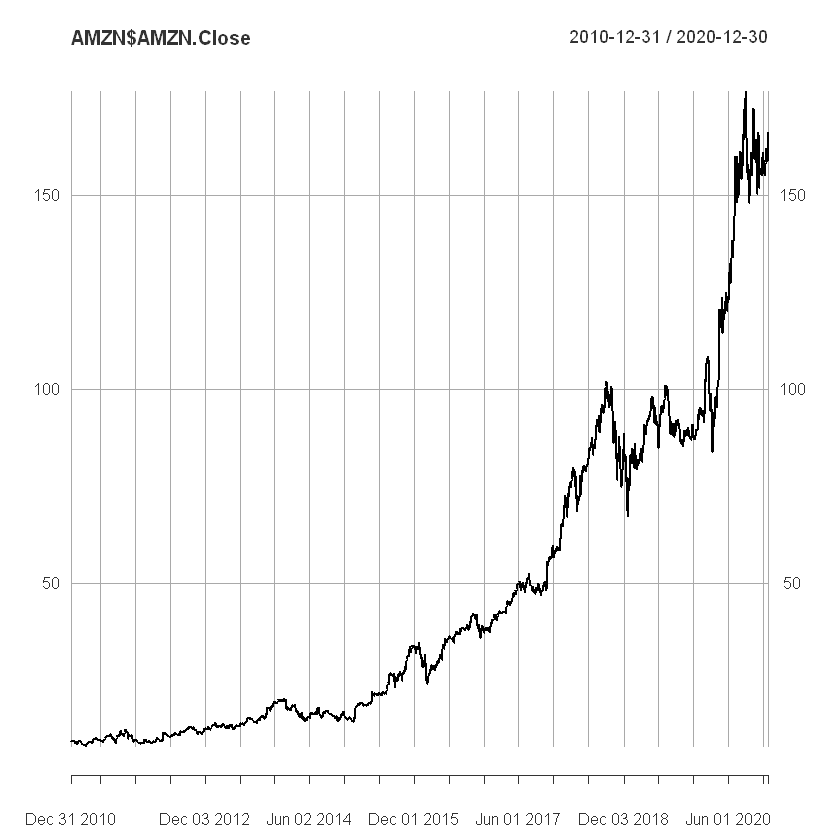

In [6]:
par(mfrow = c(1,1))
plot(AMZN$AMZN.Close)

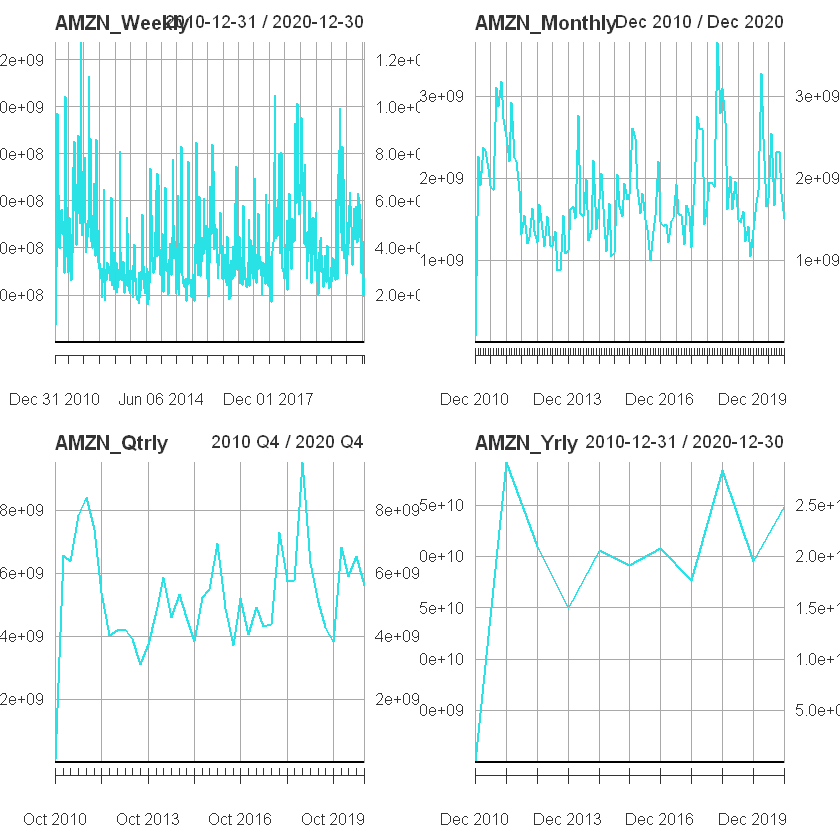

In [8]:
par(mfrow = c(2,2))
AMZN_Weekly = to.weekly(AMZN)
AMZN_Monthly= to.monthly(AMZN)
AMZN_Qtrly = to.quarterly(AMZN)
AMZN_Yrly = to.yearly(AMZN)
plot(AMZN_Weekly)
plot(AMZN_Monthly)
plot(AMZN_Qtrly)
plot(AMZN_Yrly)

### OHLC data
Open high low close

In [11]:
OHLC = AMZN_Monthly[,c(-6)]
head(OHLC)
AMZN.ohlc = as.quantmod.OHLC(OHLC, col.names = c("OPEN", "HIGH","LOW","CLOSe","VOL"))
head(AMZN.ohlc)


         AMZN.Open AMZN.High AMZN.Low AMZN.Close AMZN.Volume
Dec 2010    9.0980    9.1150   8.9755     9.0000    69038000
Jan 2011    9.0685    9.5800   8.3450     8.4820  2272226000
Feb 2011    8.5260    9.5700   8.4755     8.6645  1915528000
Mar 2011    8.6765    9.0785   8.0295     9.0065  2379582000
Apr 2011    9.0790    9.8900   8.7685     9.7905  2334988000
May 2011    9.8285   10.3195   9.5440     9.8345  2125490000

         OHLC.OPEN OHLC.HIGH OHLC.LOW OHLC.CLOSe   OHLC.VOL
Dec 2010    9.0980    9.1150   8.9755     9.0000   69038000
Jan 2011    9.0685    9.5800   8.3450     8.4820 2272226000
Feb 2011    8.5260    9.5700   8.4755     8.6645 1915528000
Mar 2011    8.6765    9.0785   8.0295     9.0065 2379582000
Apr 2011    9.0790    9.8900   8.7685     9.7905 2334988000
May 2011    9.8285   10.3195   9.5440     9.8345 2125490000

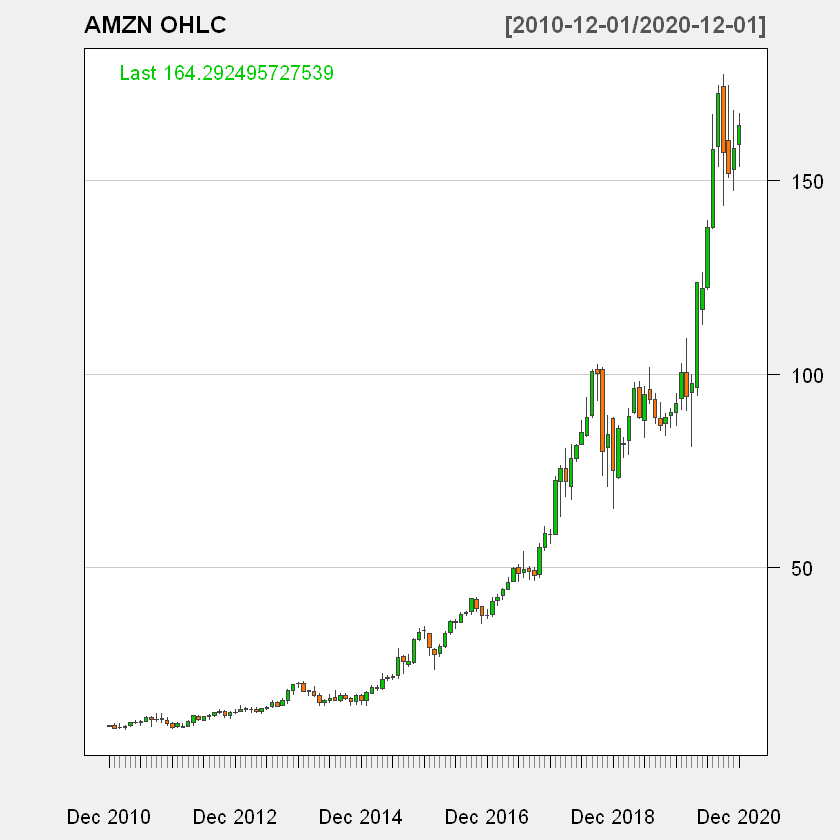

In [12]:
chartSeries(AMZN.ohlc,theme = "white",name = "AMZN OHLC")

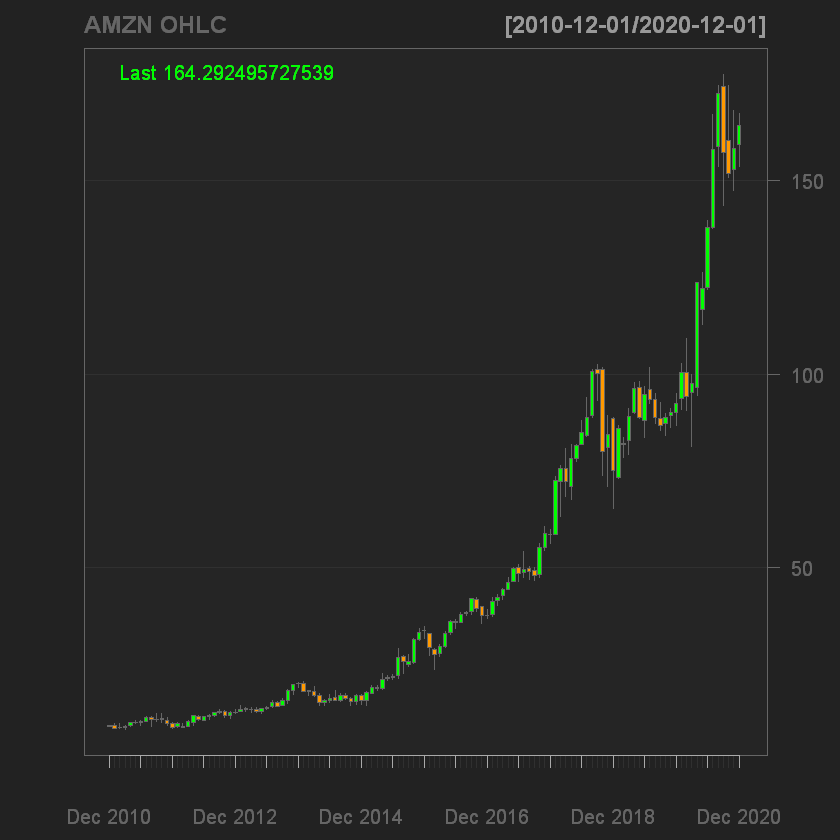

In [13]:
chartSeries(AMZN.ohlc,theme = "black",name = "AMZN OHLC")

In [14]:
AMZN = getSymbols("AMZN", from = "2010-12-31",to = "2020-12-31", auto.assign = F)
NIFTY= getSymbols("^NSEI", from = "2010-12-31",to = "2020-12-31", auto.assign = F)
GOOG  = getSymbols("GOOG", from = "2010-12-31",to = "2020-12-31", auto.assign = F)
AAPL  = getSymbols("AAPL", from = "2010-12-31",to = "2020-12-31", auto.assign = F)

Warning message:
"^NSEI contains missing values. Some functions will not work if objects contain missing values in the middle of the series. Consider using na.omit(), na.approx(), na.fill(), etc to remove or replace them."


In [15]:
Closing = cbind.zoo(AMZN$AMZN.Close, NIFTY$NSEI.Close, GOOG$GOOG.Close, AAPL$AAPL.Close)
dim(Closing)

[1] 2595    4

In [16]:
AMZN_Return = dailyReturn(AMZN$AMZN.Close, type = "log")
NIFTY_Return= dailyReturn(NIFTY$NSEI.Close, type = "log")
GOOG_Return= dailyReturn(GOOG$GOOG.Close, type = "log")
AAPL_Return= dailyReturn(AAPL$AAPL.Close, type = "log")
Return =cbind.zoo(AMZN = AMZN_Return, NIFTY = NIFTY_Return, GOOG = GOOG_Return, AAPL = AAPL_Return)
head(Return)

Warning message in to_period(xx, period = on.opts[[period]], ...):
"missing values removed from data"


           daily.returns.AMZN daily.returns.NIFTY daily.returns.GOOG
2010-12-31        0.000000000         0.000000000        0.000000000
2011-01-03        0.023173893         0.003758532        0.017324664
2011-01-04        0.004279104        -0.001828682       -0.003696751
2011-01-05        0.012942271        -0.010886657        0.011476522
2011-01-06       -0.008358393        -0.005202795        0.007246989
2011-01-07       -0.001992765        -0.024037249        0.004780697
           daily.returns.AAPL
2010-12-31       0.0000000000
2011-01-03       0.0214995684
2011-01-04       0.0052053885
2011-01-05       0.0081467738
2011-01-06      -0.0008086087
2011-01-07       0.0071359201

In [19]:
Ret = sapply(Closing, function(x) diff(log(x)))
head(Ret)
Return = na.omit(Return)

AMZN.Close,NSEI.Close,GOOG.Close,AAPL.Close
0.023173893,0.003758532,0.017324664,0.0214995684
0.004279104,-0.001828682,-0.003696751,0.0052053885
0.012942271,-0.010886657,0.011476522,0.0081467738
-0.008358393,-0.005202795,0.007246989,-0.0008086087
-0.001992765,-0.024037249,0.004780697,0.0071359201
-0.004376341,-0.024299564,-0.003624054,0.0186574166


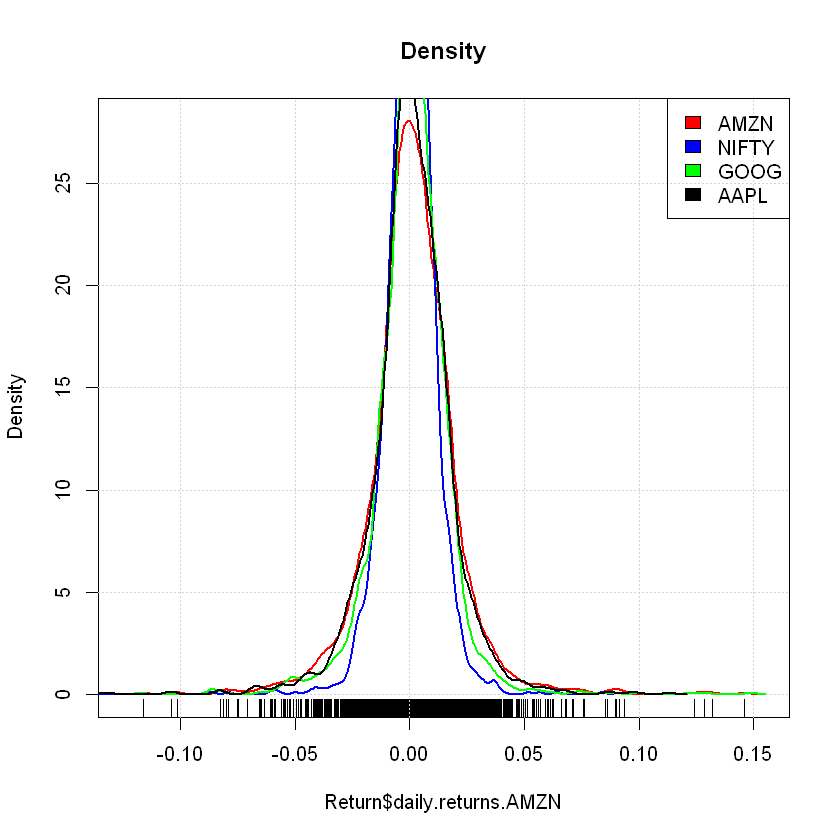

In [21]:
par(mfrow = c(1,1))
densityPlot(Return$daily.returns.AMZN, lwd = 2, col = "red", main = "Density")
lines(density(Return$daily.returns.NIFTY), lwd = 2, col = 'blue')
lines(density(Return$daily.returns.GOOG), lwd = 2, col = 'green')
lines(density(Return$daily.returns.AAPL), lwd = 2, col = 'black')
legend("topright", c("AMZN","NIFTY","GOOG","AAPL"), fill = c("red", 'blue','green','black'))